In [1]:
# =============================================================================
# CNN WIND SPEED FORECASTING WITH HYPERPARAMETER OPTIMIZATION
# =============================================================================
# Univariate wind speed forecasting (WS10M) using a 1D Convolutional Neural
# Network (CNN) with a sliding window of 3 time steps. Four training
# strategies are compared:
#   1. Original Model  (manual hyperparameters, no tuning)
#   2. Grid Search
#   3. Randomized Search
#   4. Optuna Bayesian Optimisation
#
# Data split: 80% train | 20% test (chronological, no shuffling).
# All hyperparameter tuning is performed exclusively on training data
# using TimeSeriesSplit cross-validation to prevent data leakage.
# =============================================================================

# ─────────────────────────────────────────────────────────────────────────────
# SECTION 1: PACKAGE INSTALLATION
# ─────────────────────────────────────────────────────────────────────────────

! pip install optuna
# pip install scikit-learn
# pip install tensorflow



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 15.5 MB/s eta 0:00:00


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 2: IMPORT LIBRARIES
# ─────────────────────────────────────────────────────────────────────────────

# Standard libraries
import random
import warnings
warnings.filterwarnings("ignore")

# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Dense, Flatten
from tensorflow.keras.optimizers import Adam

# Scikit-learn
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import TimeSeriesSplit, ParameterGrid, ParameterSampler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import randint, loguniform

# Optuna for Bayesian optimisation
import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)   # Suppress verbose output

# ─────────────────────────────────────────────────────────────────────────────
# SECTION 3: REPRODUCIBILITY SEEDS
# ─────────────────────────────────────────────────────────────────────────────

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 4: LOAD DATASET
# ─────────────────────────────────────────────────────────────────────────────

# Dataset source (Google Sheets exported as CSV):
# https://docs.google.com/spreadsheets/d/1j_Euo80PrGckVDVr2hTG9zZebxJD0TSC

sheet_id   = "1j_Euo80PrGckVDVr2hTG9zZebxJD0TSC"
sheet_name = "Sheet1"
csv_url    = (
    f"https://docs.google.com/spreadsheets/d/{sheet_id}"
    f"/gviz/tq?tqx=out:csv&sheet={sheet_name}"
)

# Read the Google Sheet as CSV
df = pd.read_csv(csv_url)

# Backup original DataFrame before any modifications
df_backup = df.copy()

# Set Date as the index
df = df.set_index('Date')

# Keep only the target variable: Wind Speed at 10 metres (WS10M)
df = df[['WS10M']]

print("Dataset loaded. Shape:", df.shape)
print(df.head())

Dataset loaded. Shape: (4017, 1)
                     WS10M
Date                      
2013-01-01 00:00:00   3.99
2013-01-02 00:00:00   4.25
2013-01-03 00:00:00   4.75
2013-01-04 00:00:00   5.74
2013-01-05 00:00:00   5.79


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 5: SEQUENCE CONSTRUCTION & TRAIN-TEST SPLIT
# ─────────────────────────────────────────────────────────────────────────────
# A sliding window of size 3 is used to create input-output pairs for the CNN.
# The split is performed on the raw (unscaled) sequences to keep the scaler
# fitting strictly within the training portion.
#
# NOTE: The MinMaxScaler is fit ONLY on the training target values and then
# applied to the test set. Fitting on the full series before splitting would
# cause data leakage, because the test set statistics would influence the
# training transform. This was present in the original code and is corrected here.

def create_sequences(data, window_size):
    """
    Convert a 1-D time series into supervised learning sequences.

    Parameters:
        data        : 1-D numpy array of target values
        window_size : int, number of past time steps used as input

    Returns:
        X : array of shape (n_samples, window_size)
        y : array of shape (n_samples,)
    """
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i + window_size])
        y.append(data[i + window_size])
    return np.array(X), np.array(y)


# Window size equals the number of lag terms
window_size = 3

# Build sequences from RAW (unscaled) values
raw_values = df['WS10M'].values
X_raw, y_raw = create_sequences(raw_values, window_size)

# Chronological 80/20 split
split_index = int(len(X_raw) * 0.8)
X_train_raw, X_test_raw = X_raw[:split_index], X_raw[split_index:]
y_train_raw, y_test_raw = y_raw[:split_index], y_raw[split_index:]

# Fit scaler on training target values only, then transform both sets
scaler = MinMaxScaler()
y_train_scaled = scaler.fit_transform(y_train_raw.reshape(-1, 1)).flatten()
y_test_scaled  = scaler.transform(y_test_raw.reshape(-1, 1)).flatten()

# Scale input sequences using the same scaler
X_train_scaled = scaler.transform(X_train_raw.reshape(-1, 1)).reshape(X_train_raw.shape)
X_test_scaled  = scaler.transform(X_test_raw.reshape(-1, 1)).reshape(X_test_raw.shape)

# Reshape for CNN input: (samples, time steps, features)
X_train = X_train_scaled[..., np.newaxis]
X_test  = X_test_scaled[..., np.newaxis]

print(f"\nX_train shape : {X_train.shape}")
print(f"y_train shape : {y_train_scaled.shape}")
print(f"X_test shape  : {X_test.shape}")
print(f"y_test shape  : {y_test_scaled.shape}")


X_train shape : (3211, 3, 1)
y_train shape : (3211,)
X_test shape  : (803, 3, 1)
y_test shape  : (803,)


In [5]:

# ─────────────────────────────────────────────────────────────────────────────
# SECTION 6: HELPER FUNCTIONS
# ─────────────────────────────────────────────────────────────────────────────

def evaluate_model(y_true_orig, y_pred_orig, model_name):
    """
    Calculate and print regression performance metrics.

    Parameters:
        y_true_orig : array-like, actual values in original scale
        y_pred_orig : array-like, predicted values in original scale
        model_name  : str, label for display

    Returns:
        mse, rmse, mae, mape, r2
    """
    y_true = np.array(y_true_orig).flatten()
    y_pred = np.array(y_pred_orig).flatten()

    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2   = r2_score(y_true, y_pred)

    print(f"\n{model_name} Evaluation:")
    print(f"  MSE       : {mse:.4f}")
    print(f"  RMSE      : {rmse:.4f}")
    print(f"  MAE       : {mae:.4f}")
    print(f"  MAPE      : {mape:.2f}%")
    print(f"  R-squared : {r2:.4f}")

    return mse, rmse, mae, mape, r2


def inverse_and_evaluate(y_true_scaled, y_pred_scaled, model_name):
    """
    Inverse-scale predictions and true values, then evaluate.

    Returns:
        y_true_inv, y_pred_inv, (mse, rmse, mae, mape, r2)
    """
    y_true_inv = scaler.inverse_transform(
        np.array(y_true_scaled).reshape(-1, 1)
    ).flatten()
    y_pred_inv = scaler.inverse_transform(
        np.array(y_pred_scaled).reshape(-1, 1)
    ).flatten()
    metrics = evaluate_model(y_true_inv, y_pred_inv, model_name)
    return y_true_inv, y_pred_inv, metrics


def build_cnn(filters, kernel_size, lr, input_shape):
    """
    Build and compile a single-layer 1D CNN for regression.

    Parameters:
        filters      : int, number of convolutional filters
        kernel_size  : int, size of the convolutional kernel
        lr           : float, learning rate for the Adam optimiser
        input_shape  : tuple, (time steps, features)

    Returns:
        compiled Keras Sequential model
    """
    model = Sequential([
        Conv1D(filters=filters, kernel_size=kernel_size,
               activation='relu', input_shape=input_shape),
        Flatten(),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=lr), loss='mse')
    return model


def plot_predictions(y_true_train, y_pred_train,
                     y_true_test,  y_pred_test,
                     title):
    """
    Plot actual vs predicted values for both train and test sets.
    """
    plt.figure(figsize=(14, 6))
    plt.plot(y_true_train, label='Train Actual',    color='blue',   linestyle='dashed', alpha=0.8)
    plt.plot(y_pred_train, label='Train Predicted', color='cyan',                       alpha=0.8)
    # Offset test series so it appears after the training series on the x-axis
    offset = len(y_true_train)
    plt.plot(range(offset, offset + len(y_true_test)), y_true_test,
             label='Test Actual',    color='orange', linestyle='dashed', alpha=0.8)
    plt.plot(range(offset, offset + len(y_pred_test)), y_pred_test,
             label='Test Predicted', color='red',                        alpha=0.8)
    plt.title(title)
    plt.xlabel("Sample Index")
    plt.ylabel("Wind Speed (WS10M)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()



Epoch 1/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0333
Epoch 2/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0090
Epoch 3/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0084
Epoch 4/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0083
Epoch 5/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0083
Epoch 6/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0083
Epoch 7/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0083
Epoch 8/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0083
Epoch 9/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0083
Epoch 10/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0083
Epoch 11/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0083
Epoch 12/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0083
Epoch 13/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0083
Epoch 14/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0083
Epoch 15/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - lo

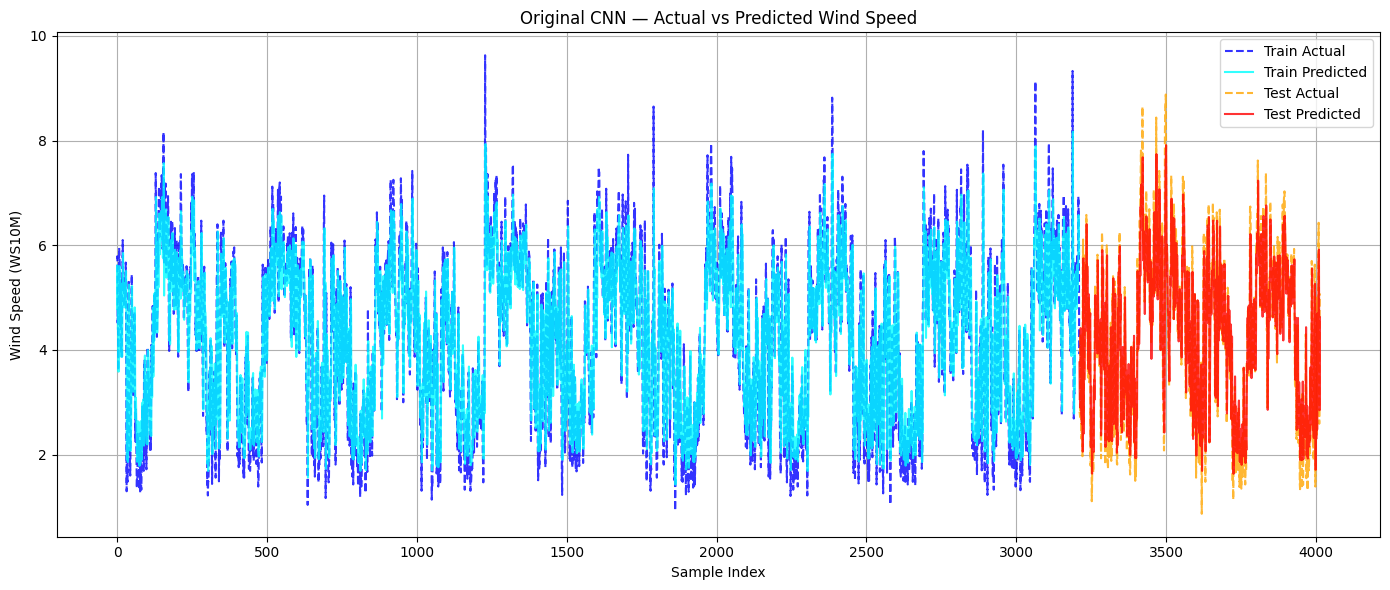

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 7: ORIGINAL CNN MODEL (Manual Hyperparameters, No Tuning)
# ─────────────────────────────────────────────────────────────────────────────

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Build CNN with manually chosen hyperparameters
model_original = build_cnn(
    filters     = 64,
    kernel_size = 2,
    lr          = 1e-3,
    input_shape = X_train.shape[1:]
)

# Train the model on the full training set
model_original.fit(
    X_train, y_train_scaled,
    epochs     = 50,
    batch_size = 16,
    verbose    = 1
)

# Predictions (scaled space)
y_pred_train_scaled_orig = model_original.predict(X_train).flatten()
y_pred_test_scaled_orig  = model_original.predict(X_test).flatten()

# Inverse scale and evaluate — train set
y_train_inv_orig, y_pred_train_inv_orig, _ = inverse_and_evaluate(
    y_train_scaled, y_pred_train_scaled_orig, "Original CNN — Train"
)

# Inverse scale and evaluate — test set
y_test_inv_orig, y_pred_test_inv_orig, _ = inverse_and_evaluate(
    y_test_scaled, y_pred_test_scaled_orig, "Original CNN — Test"
)

# Store metrics
ORIG_TRAIN_MSE, ORIG_TRAIN_RMSE, ORIG_TRAIN_MAE, ORIG_TRAIN_MAPE, ORIG_TRAIN_R2 = \
    evaluate_model(y_train_inv_orig, y_pred_train_inv_orig, "Original CNN — Train")

ORIG_TEST_MSE, ORIG_TEST_RMSE, ORIG_TEST_MAE, ORIG_TEST_MAPE, ORIG_TEST_R2 = \
    evaluate_model(y_test_inv_orig, y_pred_test_inv_orig, "Original CNN — Test")

# Plot actual vs predicted
plot_predictions(
    y_train_inv_orig, y_pred_train_inv_orig,
    y_test_inv_orig,  y_pred_test_inv_orig,
    title="Original CNN — Actual vs Predicted Wind Speed"
)


Best Parameters (Grid Search): {'batch_size': 16, 'epochs': 50, 'filters': 64, 'kernel_size': 3, 'lr': 0.0003}
Epoch 1/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0543
Epoch 2/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0104
Epoch 3/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0090
Epoch 4/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0086
Epoch 5/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0083
Epoch 6/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0082
Epoch 7/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0082
Epoch 8/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0081
Epoch 9/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0081
Epoch 10/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0081
Epoch 11/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0081
Epoch 12/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0081
Epoch 13/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0081
Epoch 14/50
2

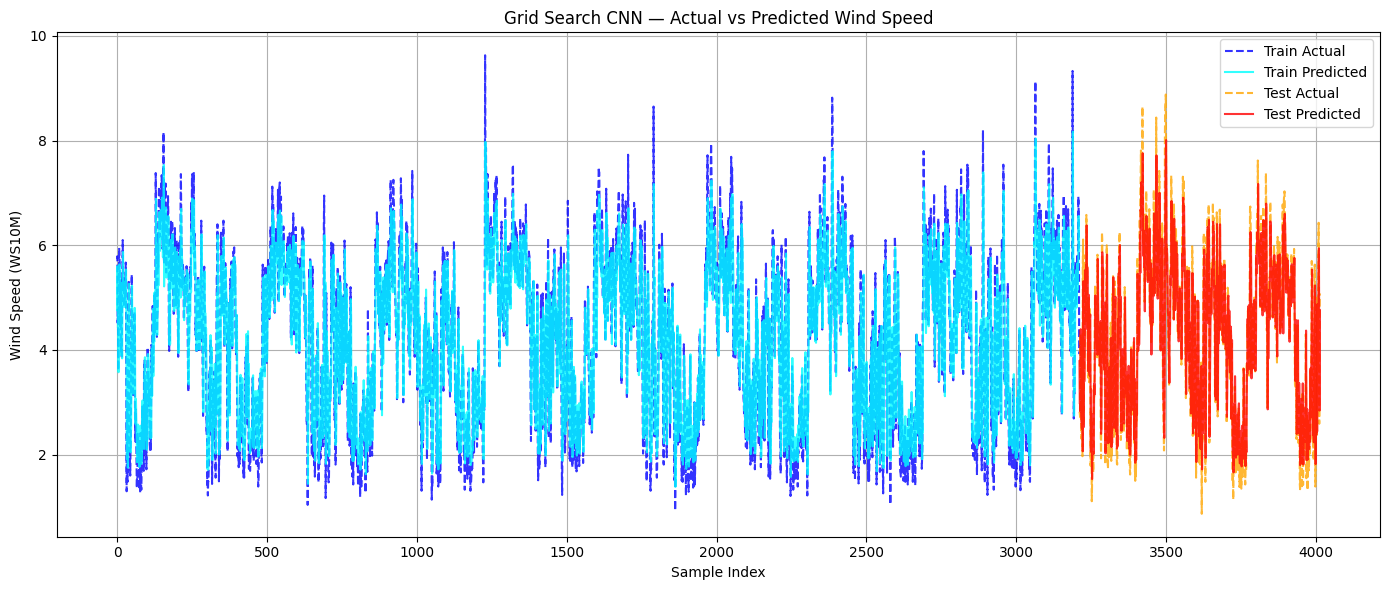

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 8: GRID SEARCH HYPERPARAMETER TUNING
# ─────────────────────────────────────────────────────────────────────────────
# NOTE: TimeSeriesSplit is used to preserve temporal ordering in CV folds
# and prevent future data from leaking into training folds.

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Define the hyperparameter search grid
param_grid = {
    'filters':     [32, 64, 128],
    'kernel_size': [1, 2, 3],
    'lr':          [1e-4, 3e-4],
    'batch_size':  [8, 16, 32],
    'epochs':      [10, 30, 50]
}

tscv_grid    = TimeSeriesSplit(n_splits=3)
best_loss_grid   = float('inf')
best_params_grid = None

# Grid search over all parameter combinations using TimeSeriesSplit CV
for params in ParameterGrid(param_grid):
    val_losses = []
    for train_idx, val_idx in tscv_grid.split(X_train):
        X_t, X_v = X_train[train_idx], X_train[val_idx]
        y_t, y_v = y_train_scaled[train_idx], y_train_scaled[val_idx]

        m = build_cnn(params['filters'], params['kernel_size'],
                      params['lr'], X_train.shape[1:])
        m.fit(X_t, y_t, epochs=params['epochs'],
              batch_size=params['batch_size'], verbose=0)
        val_losses.append(m.evaluate(X_v, y_v, verbose=0))

    mean_val_loss = np.mean(val_losses)
    if mean_val_loss < best_loss_grid:
        best_loss_grid   = mean_val_loss
        best_params_grid = params

print(f"\nBest Parameters (Grid Search): {best_params_grid}")

# Retrain final model on the FULL training set using best parameters
model_grid = build_cnn(
    best_params_grid['filters'],
    best_params_grid['kernel_size'],
    best_params_grid['lr'],
    X_train.shape[1:]
)
model_grid.fit(
    X_train, y_train_scaled,
    epochs     = best_params_grid['epochs'],
    batch_size = best_params_grid['batch_size'],
    verbose    = 1
)

# Predictions (scaled space)
y_pred_train_scaled_grid = model_grid.predict(X_train).flatten()
y_pred_test_scaled_grid  = model_grid.predict(X_test).flatten()

# Inverse scale and evaluate — train set
y_train_inv_grid, y_pred_train_inv_grid, _ = inverse_and_evaluate(
    y_train_scaled, y_pred_train_scaled_grid, "Grid Search CNN — Train"
)

# Inverse scale and evaluate — test set
y_test_inv_grid, y_pred_test_inv_grid, _ = inverse_and_evaluate(
    y_test_scaled, y_pred_test_scaled_grid, "Grid Search CNN — Test"
)

# Store metrics
GRID_TRAIN_MSE, GRID_TRAIN_RMSE, GRID_TRAIN_MAE, GRID_TRAIN_MAPE, GRID_TRAIN_R2 = \
    evaluate_model(y_train_inv_grid, y_pred_train_inv_grid, "Grid Search CNN — Train")

GRID_TEST_MSE, GRID_TEST_RMSE, GRID_TEST_MAE, GRID_TEST_MAPE, GRID_TEST_R2 = \
    evaluate_model(y_test_inv_grid, y_pred_test_inv_grid, "Grid Search CNN — Test")

# Plot actual vs predicted
plot_predictions(
    y_train_inv_grid, y_pred_train_inv_grid,
    y_test_inv_grid,  y_pred_test_inv_grid,
    title="Grid Search CNN — Actual vs Predicted Wind Speed"
)


Best Parameters (Randomized Search): {'batch_size': 8, 'epochs': 48, 'filters': 114, 'kernel_size': 3, 'lr': np.float64(0.00013066739238053285)}
Epoch 1/48
402/402 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.1127
Epoch 2/48
402/402 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0124
Epoch 3/48
402/402 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0098
Epoch 4/48
402/402 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0089
Epoch 5/48
402/402 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0085
Epoch 6/48
402/402 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0083
Epoch 7/48
402/402 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0082
Epoch 8/48
402/402 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0082
Epoch 9/48
402/402 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0081
Epoch 10/48
402/402 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0081
Epoch 11/48
402/402 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0081
Epoch 12/48
402/402 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0081
Epoch 13/48
402/402 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms

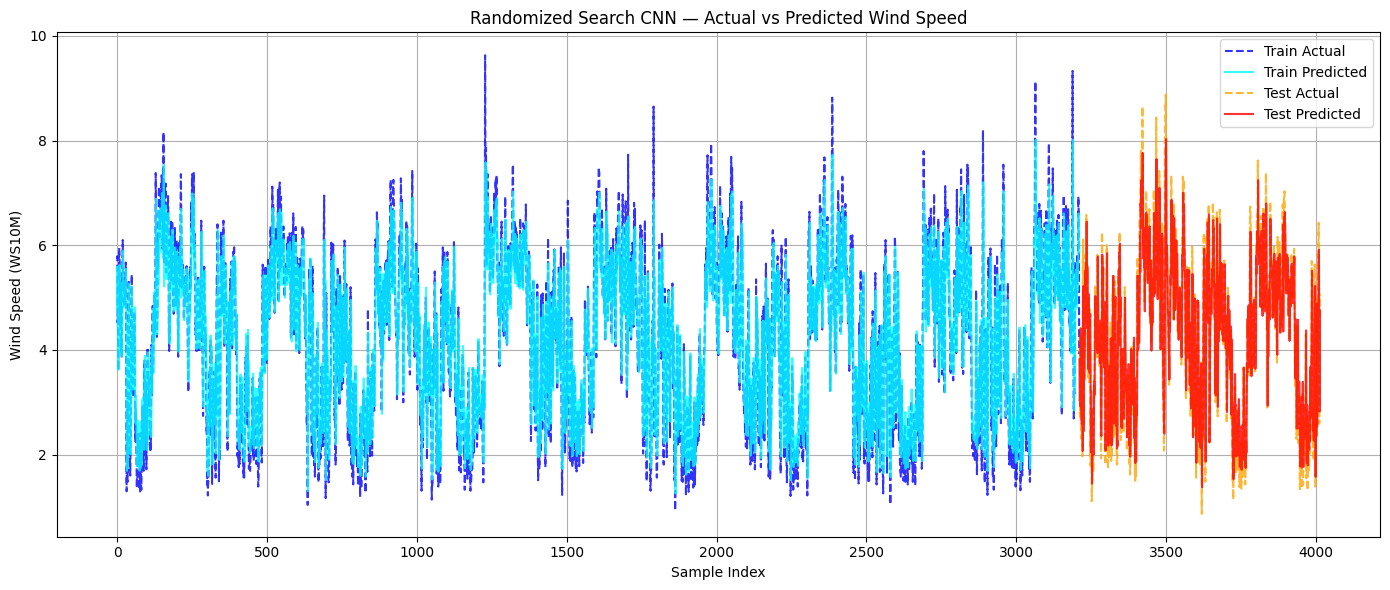

In [8]:

# ─────────────────────────────────────────────────────────────────────────────
# SECTION 9: RANDOMIZED SEARCH HYPERPARAMETER TUNING
# ─────────────────────────────────────────────────────────────────────────────
# NOTE: TimeSeriesSplit is used to preserve temporal ordering in CV folds.

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Define the hyperparameter distribution for random sampling
param_dist = {
    'filters':     randint(32, 129),          # Integers from 32 to 128
    'kernel_size': randint(1, 4),             # Integers 1 to 3
    'lr':          loguniform(1e-4, 1e-2),    # Log scale for learning rate
    'batch_size':  [8, 16, 32],
    'epochs':      randint(10, 51)
}

n_iter_search  = 10   # Number of random combinations to try
random_samples = list(ParameterSampler(param_dist, n_iter=n_iter_search,
                                        random_state=SEED))

tscv_random      = TimeSeriesSplit(n_splits=5)
best_loss_random   = float('inf')
best_params_random = None

# Random search over sampled parameter combinations using TimeSeriesSplit CV
for params in random_samples:
    val_losses = []
    for train_idx, val_idx in tscv_random.split(X_train):
        X_t, X_v = X_train[train_idx], X_train[val_idx]
        y_t, y_v = y_train_scaled[train_idx], y_train_scaled[val_idx]

        m = build_cnn(params['filters'], params['kernel_size'],
                      params['lr'], X_train.shape[1:])
        m.fit(X_t, y_t, epochs=params['epochs'],
              batch_size=params['batch_size'], verbose=0)
        val_losses.append(m.evaluate(X_v, y_v, verbose=0))

    mean_val_loss = np.mean(val_losses)
    if mean_val_loss < best_loss_random:
        best_loss_random   = mean_val_loss
        best_params_random = params

print(f"\nBest Parameters (Randomized Search): {best_params_random}")

# Retrain final model on the FULL training set using best parameters
model_random = build_cnn(
    best_params_random['filters'],
    best_params_random['kernel_size'],
    best_params_random['lr'],
    X_train.shape[1:]
)
model_random.fit(
    X_train, y_train_scaled,
    epochs     = best_params_random['epochs'],
    batch_size = best_params_random['batch_size'],
    verbose    = 1
)

# Predictions (scaled space)
y_pred_train_scaled_random = model_random.predict(X_train).flatten()
y_pred_test_scaled_random  = model_random.predict(X_test).flatten()

# Inverse scale and evaluate — train set
y_train_inv_random, y_pred_train_inv_random, _ = inverse_and_evaluate(
    y_train_scaled, y_pred_train_scaled_random, "Randomized Search CNN — Train"
)

# Inverse scale and evaluate — test set
y_test_inv_random, y_pred_test_inv_random, _ = inverse_and_evaluate(
    y_test_scaled, y_pred_test_scaled_random, "Randomized Search CNN — Test"
)

# Store metrics
RANDOM_TRAIN_MSE, RANDOM_TRAIN_RMSE, RANDOM_TRAIN_MAE, RANDOM_TRAIN_MAPE, RANDOM_TRAIN_R2 = \
    evaluate_model(y_train_inv_random, y_pred_train_inv_random, "Randomized Search CNN — Train")

RANDOM_TEST_MSE, RANDOM_TEST_RMSE, RANDOM_TEST_MAE, RANDOM_TEST_MAPE, RANDOM_TEST_R2 = \
    evaluate_model(y_test_inv_random, y_pred_test_inv_random, "Randomized Search CNN — Test")

# Plot actual vs predicted
plot_predictions(
    y_train_inv_random, y_pred_train_inv_random,
    y_test_inv_random,  y_pred_test_inv_random,
    title="Randomized Search CNN — Actual vs Predicted Wind Speed"
)




Best Parameters (Optuna): {'batch_size': 8, 'epochs': 15, 'filters': 118, 'kernel_size': 3, 'lr': 0.000640543063838734}
Epoch 1/15
402/402 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0261
Epoch 2/15
402/402 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0085
Epoch 3/15
402/402 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0083
Epoch 4/15
402/402 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0082
Epoch 5/15
402/402 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0082
Epoch 6/15
402/402 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0082
Epoch 7/15
402/402 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0082
Epoch 8/15
402/402 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0082
Epoch 9/15
402/402 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0082
Epoch 10/15
402/402 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0082
Epoch 11/15
402/402 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0082
Epoch 12/15
402/402 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0081
Epoch 13/15
402/402 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0081
Epoc

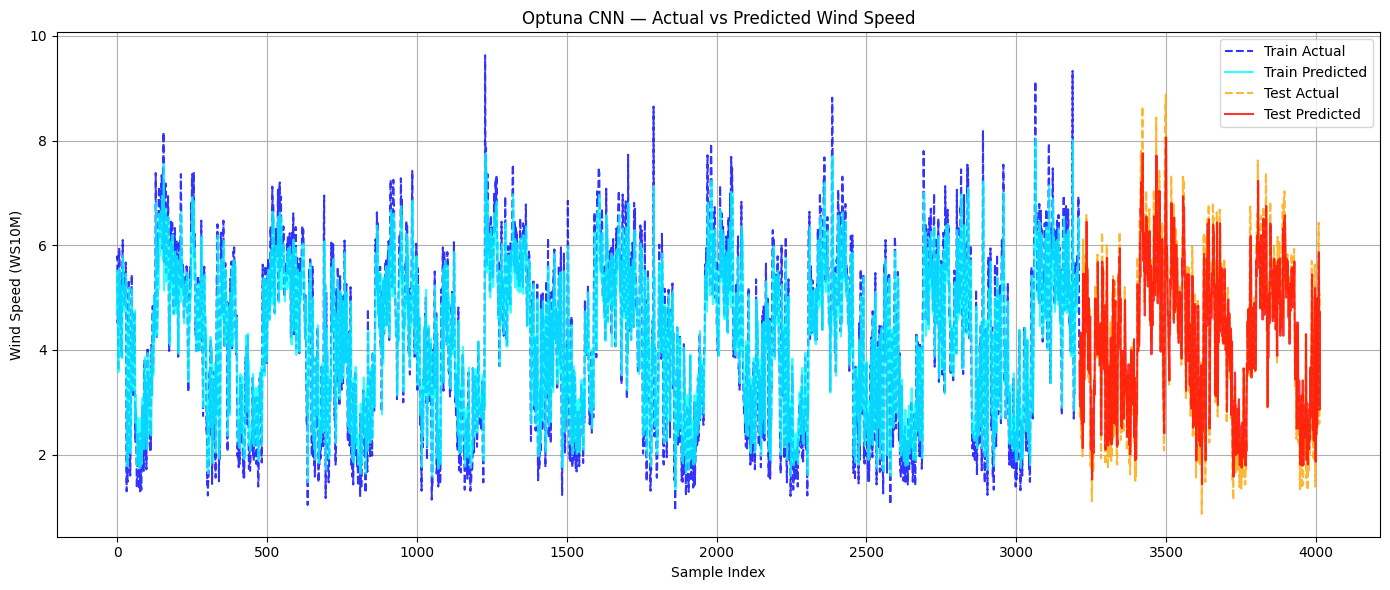

In [9]:

# ─────────────────────────────────────────────────────────────────────────────
# SECTION 10: OPTUNA BAYESIAN HYPERPARAMETER OPTIMISATION
# ─────────────────────────────────────────────────────────────────────────────
# NOTE: The Optuna objective uses TimeSeriesSplit on the training set only.
# The test set is never accessed inside the objective function, ensuring
# no data leakage from the test set into the tuning process.
#
# NOTE: suggest_loguniform() is deprecated in modern Optuna versions.
# Replaced with suggest_float(..., log=True).

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


def create_model_optuna(trial, input_shape):
    """
    Build a CNN model with architecture suggested by an Optuna trial.

    Parameters:
        trial       : optuna.Trial object
        input_shape : tuple, (time steps, features)

    Returns:
        compiled Keras Sequential model
    """
    filters     = trial.suggest_int(  'filters',     32,  128)
    kernel_size = trial.suggest_int(  'kernel_size',  1,    3)
    # NOTE: suggest_loguniform is deprecated — using suggest_float with log=True
    lr          = trial.suggest_float('lr',          1e-4, 1e-2, log=True)

    return build_cnn(filters, kernel_size, lr, input_shape)


def objective_optuna(trial):
    """
    Optuna objective: trains a CNN with trial hyperparameters using
    TimeSeriesSplit CV on the training set and returns mean validation MSE.
    The test set is NOT used here.
    """
    tscv_opt   = TimeSeriesSplit(n_splits=3)
    batch_size = trial.suggest_categorical('batch_size', [8, 16, 32])
    epochs     = trial.suggest_int('epochs', 10, 50)

    val_losses = []
    for train_idx, val_idx in tscv_opt.split(X_train):
        X_t, X_v = X_train[train_idx], X_train[val_idx]
        y_t, y_v = y_train_scaled[train_idx], y_train_scaled[val_idx]

        m = create_model_optuna(trial, input_shape=X_train.shape[1:])
        m.fit(X_t, y_t, epochs=epochs, batch_size=batch_size, verbose=0)
        val_losses.append(m.evaluate(X_v, y_v, verbose=0))

    return np.mean(val_losses)


# Run Optuna study — minimise validation MSE using training data only
study = optuna.create_study(
    direction = 'minimize',
    sampler   = TPESampler(seed=SEED)
)
study.optimize(objective_optuna, n_trials=30)

best_params_optuna = study.best_trial.params
print(f"\nBest Parameters (Optuna): {best_params_optuna}")

# Retrain final model on the FULL training set using best parameters
model_optuna = build_cnn(
    filters     = best_params_optuna['filters'],
    kernel_size = best_params_optuna['kernel_size'],
    lr          = best_params_optuna['lr'],
    input_shape = X_train.shape[1:]
)
model_optuna.fit(
    X_train, y_train_scaled,
    epochs     = best_params_optuna['epochs'],
    batch_size = best_params_optuna['batch_size'],
    verbose    = 1
)

# Predictions (scaled space)
y_pred_train_scaled_optuna = model_optuna.predict(X_train).flatten()
y_pred_test_scaled_optuna  = model_optuna.predict(X_test).flatten()

# Inverse scale and evaluate — train set
y_train_inv_optuna, y_pred_train_inv_optuna, _ = inverse_and_evaluate(
    y_train_scaled, y_pred_train_scaled_optuna, "Optuna CNN — Train"
)

# Inverse scale and evaluate — test set
y_test_inv_optuna, y_pred_test_inv_optuna, _ = inverse_and_evaluate(
    y_test_scaled, y_pred_test_scaled_optuna, "Optuna CNN — Test"
)

# Store metrics
OPTUNA_TRAIN_MSE, OPTUNA_TRAIN_RMSE, OPTUNA_TRAIN_MAE, OPTUNA_TRAIN_MAPE, OPTUNA_TRAIN_R2 = \
    evaluate_model(y_train_inv_optuna, y_pred_train_inv_optuna, "Optuna CNN — Train")

OPTUNA_TEST_MSE, OPTUNA_TEST_RMSE, OPTUNA_TEST_MAE, OPTUNA_TEST_MAPE, OPTUNA_TEST_R2 = \
    evaluate_model(y_test_inv_optuna, y_pred_test_inv_optuna, "Optuna CNN — Test")

# Plot actual vs predicted
plot_predictions(
    y_train_inv_optuna, y_pred_train_inv_optuna,
    y_test_inv_optuna,  y_pred_test_inv_optuna,
    title="Optuna CNN — Actual vs Predicted Wind Speed"
)



In [10]:

# ─────────────────────────────────────────────────────────────────────────────
# SECTION 11: COMPARATIVE RESULTS TABLE
# ─────────────────────────────────────────────────────────────────────────────

# Compile all evaluation metrics into a single comparison DataFrame
metrics_df = pd.DataFrame({
    "Method":     ["Original Model", "Grid Search", "Randomized Search", "Optuna"],
    "Train MSE":  [ORIG_TRAIN_MSE,   GRID_TRAIN_MSE,   RANDOM_TRAIN_MSE,   OPTUNA_TRAIN_MSE],
    "Test MSE":   [ORIG_TEST_MSE,    GRID_TEST_MSE,    RANDOM_TEST_MSE,    OPTUNA_TEST_MSE],
    "Train RMSE": [ORIG_TRAIN_RMSE,  GRID_TRAIN_RMSE,  RANDOM_TRAIN_RMSE,  OPTUNA_TRAIN_RMSE],
    "Test RMSE":  [ORIG_TEST_RMSE,   GRID_TEST_RMSE,   RANDOM_TEST_RMSE,   OPTUNA_TEST_RMSE],
    "Train MAE":  [ORIG_TRAIN_MAE,   GRID_TRAIN_MAE,   RANDOM_TRAIN_MAE,   OPTUNA_TRAIN_MAE],
    "Test MAE":   [ORIG_TEST_MAE,    GRID_TEST_MAE,    RANDOM_TEST_MAE,    OPTUNA_TEST_MAE],
    "Train MAPE": [ORIG_TRAIN_MAPE,  GRID_TRAIN_MAPE,  RANDOM_TRAIN_MAPE,  OPTUNA_TRAIN_MAPE],
    "Test MAPE":  [ORIG_TEST_MAPE,   GRID_TEST_MAPE,   RANDOM_TEST_MAPE,   OPTUNA_TEST_MAPE],
    "Train R²":   [ORIG_TRAIN_R2,    GRID_TRAIN_R2,    RANDOM_TRAIN_R2,    OPTUNA_TRAIN_R2],
    "Test R²":    [ORIG_TEST_R2,     GRID_TEST_R2,     RANDOM_TEST_R2,     OPTUNA_TEST_R2],
})

print("\nModel Comparison — Evaluation Metrics:")
print(metrics_df.to_string(index=False))

# Save the metrics DataFrame to CSV
metrics_df.to_csv("variableSet_1_CNN.csv", index=False)
print("\nMetrics saved to variableSet_1_CNN.csv")



Model Comparison — Evaluation Metrics:
           Method  Train MSE  Test MSE  Train RMSE  Test RMSE  Train MAE  Test MAE  Train MAPE  Test MAPE  Train R²  Test R²
   Original Model   0.614018  0.757736    0.783593   0.870481   0.603276  0.668377   17.710306  18.911513  0.756341 0.685775
      Grid Search   0.611730  0.754455    0.782132   0.868594   0.600358  0.666877   17.488138  18.748448  0.757249 0.687136
Randomized Search   0.616604  0.757399    0.785241   0.870287   0.603231  0.669390   17.709831  18.958216  0.755315 0.685915
           Optuna   0.620052  0.755835    0.787434   0.869388   0.606462  0.669793   17.740179  18.897834  0.753947 0.686563

Metrics saved to variableSet_1_CNN.csv
